In [1]:
using Plots
using Statistics
using StaticArrays
using Random
import Pkg
using CSV, DataFrames
using JLD2 

Pkg.activate("/Users/mckinleypaul/Documents/montecarlo/gc_wl/src/")
Pkg.activate("/Users/mckinleypaul/Documents/montecarlo/gc_wl")
using gc_wl 


  Activating new project at `~/Documents/montecarlo/gc_wl/src`
  Activating project at `~/Documents/montecarlo/gc_wl`


x=1: 0.45867514538708193
x=4: 1.1253518106650157e-7
x=5.4: 2.1671553440685403e-13
x=6: 2.220446049250313e-16
x=10: -0.0


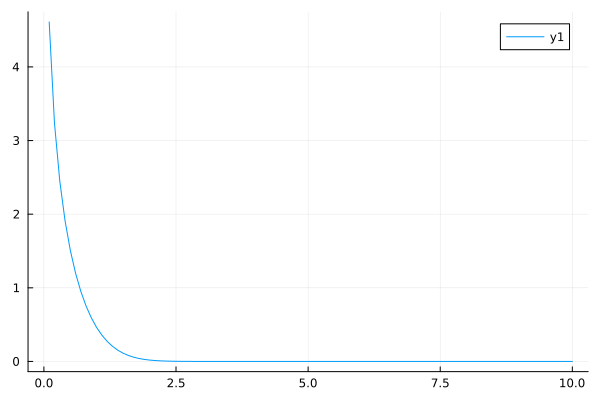

In [58]:
# deciding gaussian gas cutoff
f(x) = -log(1.0 - exp(-(x^2)) )
println("x=1: ", f(1))
println("x=4: ", f(4))
println("x=5.4: ", f(5.4))
println("x=6: ", f(6))
println("x=10: ", f(10))
plot(0:0.1:10, f.(0:0.1:10))


In [59]:
13/8000

0.001625

In [12]:
# loading in gcwl data
N350gc = load_wanglandau_jld2("/Users/mckinleypaul/Documents/montecarlo/gc_wl/examples/N350_L8_T1.2/run1/wl_checkpoint.jld2")
correct_logQ!(N350gc)

T_σ_12 = 1.2
Λ_12 = argon_deBroglie(T_σ_12)
logQstar_N350gc = N350gc.logQ_N .+ 3 .* (0:(length(N350gc.logQ_N )-1)) .* log(Λ_12);

In [ ]:
nocut1 = load_wanglandau_jld2("/Users/mckinleypaul/Documents/montecarlo/gc_wl/data/lennard_jones/no_cutoff/run1/final_wl.jld2")
nocut2 = load_wanglandau_jld2("/Users/mckinleypaul/Documents/montecarlo/gc_wl/data/lennard_jones/no_cutoff/run2/final_wl.jld2")
nocut3 = load_wanglandau_jld2("/Users/mckinleypaul/Documents/montecarlo/gc_wl/data/lennard_jones/no_cutoff/run3/final_wl.jld2")

nocut_avg = (nocut1.logQ_N .+ nocut2.logQ_N .+ nocut3.logQ_N  ) .* (1/3)

Λ_12 = argon_deBroglie(1.2)
nocut_star = nocut_avg .+ 3 .* (0:(length(nocut_avg)-1)) .* log(Λ_12);


In [14]:
# loading in segc_wl data
# JLD2 reconstructs WangLandauVars as ReconstructedMutable when the original module
# isn't loaded. Its named fields are exposed via getproperty (dot notation).

function load_segcwl_logQ(filename::String)::Vector{Float64}
    jldopen(filename, "r") do f
        wl = f["wl"]
        logQ_λN = wl.logQ_λN          # Matrix: rows = λ (1-indexed), cols = N (1-indexed)
        logC = -logQ_λN[1, 1]         # anchor: logQ(N=0, λ=0) = 0
        return logQ_λN[1, :] .+ logC  # λ=0 slice, all N
    end
end

segcwl_base = "/Users/mckinleypaul/Documents/montecarlo/segc_wl/examples/N350_L8_T1.2/M100_fixed"
logQr1 = load_segcwl_logQ(joinpath(segcwl_base, "run1", "wl_checkpoint_after_zeroing.jld2"))
logQr2 = load_segcwl_logQ(joinpath(segcwl_base, "run2", "wl_checkpoint_after_zeroing.jld2"))
logQr3 = load_segcwl_logQ(joinpath(segcwl_base, "run3", "wl_checkpoint_after_zeroing.jld2"))
logQr4 = load_segcwl_logQ(joinpath(segcwl_base, "run4", "wl_checkpoint_after_zeroing.jld2"))

logQavg = (logQr1 .+ logQr2 .+ logQr3 .+ logQr4) .* (1/4)
T_σ_12 = 1.2
Λ_12 = argon_deBroglie(T_σ_12)
logQstar_N350avg = logQavg .+ 3 .* (0:(length(logQavg)-1)) .* log(Λ_12);


┌ Warning: type segc_wl.WangLandauVars does not exist in workspace; reconstructing
└ @ JLD2 /Users/mckinleypaul/.julia/packages/JLD2/hbsZG/src/data/reconstructing_datatypes.jl:588
┌ Warning: type segc_wl.WangLandauVars does not exist in workspace; reconstructing
└ @ JLD2 /Users/mckinleypaul/.julia/packages/JLD2/hbsZG/src/data/reconstructing_datatypes.jl:588
┌ Warning: type segc_wl.WangLandauVars does not exist in workspace; reconstructing
└ @ JLD2 /Users/mckinleypaul/.julia/packages/JLD2/hbsZG/src/data/reconstructing_datatypes.jl:588
┌ Warning: type segc_wl.WangLandauVars does not exist in workspace; reconstructing
└ @ JLD2 /Users/mckinleypaul/.julia/packages/JLD2/hbsZG/src/data/reconstructing_datatypes.jl:588


In [15]:
# Load Desgranges 2012 Fig 1a reference data for T = 140.46 K (T* = 1.2)
ref_path = "/Users/mckinleypaul/Documents/montecarlo/segc_wl/literature/figure1adata/Desgranges_2012_fig_1_140K.csv"
ref_df = CSV.read(ref_path, DataFrame)
x_ref = ref_df[!, 1]
y_ref = ref_df[!, 2];

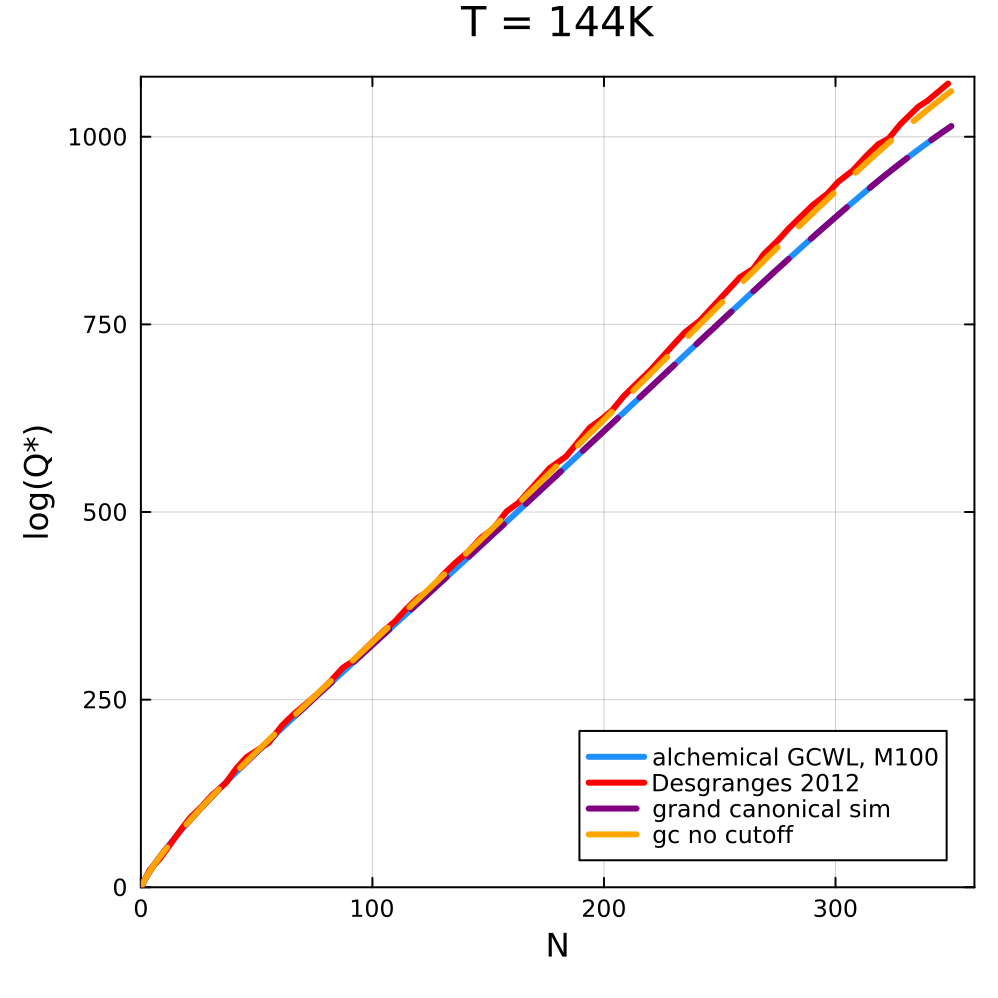

In [16]:

plot()
plot!(
    0:350, logQstar_N350avg,
    label  = "alchemical GCWL, M100",
    color  = :dodgerblue,
    lw     = 3,
    xlabel = "N",
    ylabel = "log(Q*)",
    title  = "T = 144K",
    legend = :bottomright,
    size   = (500, 500),
    dpi    = 200,
    grid   = true,
    framestyle = :box,
    linestyle = :solid,
    xlims=[0,360],
    ylims = [0,1080]
)
plot!(x_ref, y_ref, label = "Desgranges 2012", color = :red, lw = 3)
plot!(0:350, logQstar_N350avg, label = "grand canonical sim", color=:purple,lw=3, linestyle = :dash)
plot!(0:350, nocut_star, label = "gc no cutoff", color=:orange,lw=3, linestyle = :dash)

# TESTING THERMO STUFF


In [2]:
struct GaussianGas <: PairPotential end
function gc_wl.pair_energy(p::GaussianGas, r2_σ::Float64)::Float64
    # βU(r) = -ln(1 - exp(-r²/σ²)), with σ=1
    return -log(1.0 - exp(-r2_σ))
end

wl = load_wanglandau_jld2("/Users/mckinleypaul/Documents/montecarlo/gc_wl/data/gaussian_gas/error_investigation/final_wl.jld2")

sim = load_sim_jld2("/Users/mckinleypaul/Documents/montecarlo/gc_wl/data/gaussian_gas/error_investigation/sim.jld2")

logZ = compute_logZ(wl,sim)

bns, bn_Rsum, bn_Rsub, = compute_bn_from_logZ(logZ,sim)
tilde_bns, tilde_bn_Rsum,tilde_bn_Rsub = compute_bns_rescaled(logZ,sim)

([0.9933694518464605, -0.4966067057464352, 7.210368218690337e-5, 0.004226661496137817, -0.003185572312694562, 0.0012944861458369537, -0.0029052022251764014, 0.0012369824275235463, 0.0003031360267307993, 0.001591853523505317, -0.0013813450682881082, -7.26103624499427e-5, 0.0026173846255967384], [1.0, 1.0, 12731.212264216641, 122.2374703452311, 122.16163652396729, 285.5195519896855, 94.76915051082712, 229.87253853109627, 1304.2088077191245, 141.70305902907748, 125.36711007757512, 910.9969557779917, 66.55326134911367], [1.0, 1.000503416480501, 2.4672293067081252, 1.0, 1.0784788337730542, 1.0, 1.0860525294361636, 1.0, 1.0, 1.0, 1.1809830184646213, 4.44303473450293, 1.0])

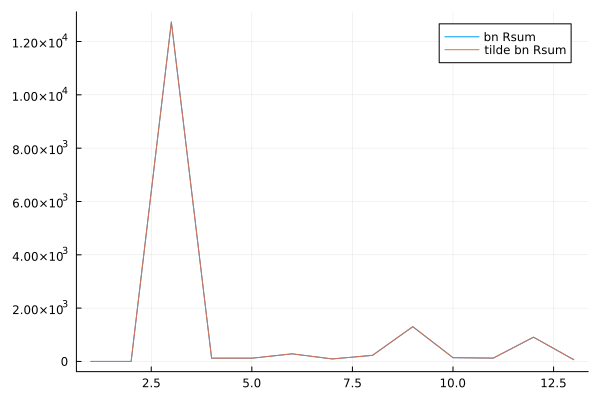

In [5]:
plot(1:length(bn_Rsum),bn_Rsum, label = "bn Rsum")
plot!(1:length(bn_Rsum),tilde_bn_Rsum, label = "tilde bn Rsum")
